# Tarea 2.7 – Eficiencia de algoritmos
**Objetivo:** determinar si el número de pasos de cada algoritmo corresponde a
$\mathcal{O}(n^c)$, $\mathcal{O}(\log_2 n)$ o $\mathcal{O}(2^n)$.


## Código 1

El primer ciclo recorre $n$ valores de $i$. Para cada uno de ellos, el segundo ciclo recorre también $n$ valores de $j$.

Por lo tanto, la condición $i < j$ se evalúa:

$$n\cdot n=n^2$$

veces.

Aunque la suma solo se realiza cuando $i < j$, los dos ciclos anidados siguen recorriendo las $n^2$ combinaciones posibles de $i$ y $j$. Por eso el orden de crecimiento es:

$$\mathcal{O}(n^2)$$

Por lo tanto, en la forma $\mathcal{O}(n^c)$:

$${c=2}$$

In [1]:
n = 1000
s = 0

for i in range(n):
    for j in range(n):
        if i < j:
            s = s + i + j

print("Valor final de s:", s)

Valor final de s: 499000500


## Código 2

En este caso, el ciclo interior no recorre siempre $n$ valores, sino que depende de $i$.

El número total de iteraciones es:

$$0+1+2+\cdots +(n-1)$$

Esta suma corresponde a:

$$\frac{n(n-1)}{2}$$

y al desarrollar:

$$\frac{n^2-n}{2}$$

Para valores grandes de $n$, el término dominante es $n^2$, por lo que:

$$\mathcal{O}(n^2)$$

y por tanto:

$${c=2}$$

In [ ]:
n = 1000
s = 0

for i in range(n):
    for j in range(i):
        s = s + i + j

print("Valor final de s:", s)

## Código 3

Aquí es importante considerar que `sum(range(n))` debe recorrer los $n$ elementos del rango para sumarlos.

Por eso:

$$\texttt{sum(range(n))}\sim\mathcal{O}(n)$$

Esta operación está dentro de un ciclo `for` que también se ejecuta $n$ veces. Entonces:

$$n\cdot n=n^2$$

Por lo tanto:

$${\mathcal{O}(n^2)}$$

y:

$${c=2}$$

In [ ]:
n = 1000
s = 0

for i in range(n):
    s = s + i + sum(range(n))

print("Valor final de s:", s)

## Código 4

Este algoritmo busca el número `p` tomando repetidamente el punto medio del intervalo.

En cada iteración se descarta aproximadamente la mitad del intervalo anterior. Por lo tanto, el tamaño del intervalo evoluciona aproximadamente como:

$$n,\quad \frac{n}{2},\quad \frac{n}{4},\quad \frac{n}{8},\ldots$$

Después de $s$ pasos:

$$\frac{n}{2^s}\approx 1$$

Entonces:

$$n\approx 2^s$$

y, tomando logaritmo en base 2:

$$s\approx \log_2 n$$

Por lo tanto, se espera que el algoritmo tenga complejidad:

$${\mathcal{O}(\log_2 n)}$$

A continuación se prueba el algoritmo para varios valores de $n$ y se grafica $n$ contra el número de pasos $s$.

In [3]:
import matplotlib.pyplot as plt

def contar_pasos(n, p=146):
    small = 0
    attempt = n // 2
    s = 0

    while True:
        s = s + 1

        if attempt > p:
            n = attempt
        elif attempt < p:
            small = attempt
        else:
            return s

        attempt = (n + small) // 2

In [4]:
valores_n = [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
valores_s = []

for n in valores_n:
    s = contar_pasos(n)
    valores_s.append(s)
    print("n =", n, "-> pasos =", s)

n = 1000 -> pasos = 9
n = 2000 -> pasos = 10
n = 4000 -> pasos = 11
n = 8000 -> pasos = 12
n = 16000 -> pasos = 13
n = 32000 -> pasos = 14
n = 64000 -> pasos = 15
n = 128000 -> pasos = 16


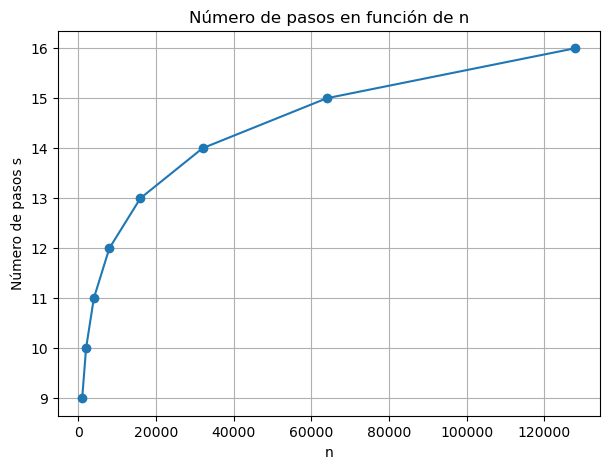

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(valores_n, valores_s, marker='o')
plt.xlabel("n")
plt.ylabel("Número de pasos s")
plt.title("Número de pasos en función de n")
plt.grid()
plt.show()

### Interpretación de la gráfica

En cada paso el intervalo se reduce aproximadamente a la mitad. Por eso, si $n$ se duplica, el número de pasos aumenta muy poco. Eso corresponde a un crecimiento logarítmico y se concluye que:

$${\mathcal{O}(\log_2 n)}$$

El número exacto de pasos puede variar para ciertos valores de $n$, porque el valor buscado `p = 146` puede coincidir antes con alguno de los puntos medios. Sin embargo, la tendencia general sigue siendo logarítmica.